# T4.1 Análisis de algoritmos: introducción y conceptos básicos

## 1. Introducción al análisis de algoritmos

Es habitual disponer de más de un programa para resolver un tipo de problema. 

Para decidir cuál es el mejor se precisan criterios objetivos: la **eficiencia** o **coste**.

El programa **más eficiente** es el que utiliza **menos recursos** al ejecutarse:
* **Consumo de memoria** (Coste espacial).
* **Consumo de tiempo** (Coste temporal).

### Factores que influyen en el coste

El coste de un programa depende de dos tipos de factores:

1. **Factores propios del programa**: 
    - la estrategia utilizada (algoritmo) 
    - el tipo de los datos.
2. **Factores circunstanciales del entorno de ejecución**: 
    - características de la CPU/GPU/memoria, 
    - sistema operativo, 
    - lenguaje de programación, 
    - compilador, 
    - carga del sistema (= existencia de otros procesos concurrentes), 
    - etc.

### Tipos de análisis
1. **Análisis teórico o a priori**: 
    - El coste se estima en función de los **factores propios del programa**. 
    - Es independiente del entorno de programación. 
    - Se realiza "en el aula" (etapa de diseño).

2. **Análisis experimental o a posteriori**: 
    - Se mide el tiempo real (segundos) y memoria (bytes) en un **entorno de ejecución particular**. 
    - Se realiza "en el laboratorio".

Ambos son complementarios, pero el **análisis teórico nos permite prever la eficiencia de un programa antes de o durante su implementación**.

Los principios de análisis teórico de la complejidad temporal y espacial de algoritmos se pueden usar incluso en la **etapa de diseño de las soluciones algorítmicas**. Esto nos hace ser conscientes de los costes en todo momento, y nos permite cambiar rápidamente de aproximación si el enfoque incial resulta ser teóricamente demasiado costoso o poco eficiente.

## 2. Coste temporal y espacial. Talla del problema

**Coste de un algoritmo**: 
* Medida de la **cantidad de tiempo o memoria que necesita el algoritmo para su ejecución**. 
* Se expresa como una **función matemática positiva y monótona**, no decreciente.
* El **coste temporal** de un algoritmo $A$ se denota como $T_A(n)$, o simplemente $T(n)$.

**Talla de un problema ($n$)**: 
* Medida del **volumen de los datos** de entrada en función de la cual expresamos el coste.
* Determinar qué es la talla de un problema es el **primer paso esencial del análisis de algoritmos**.
* Ejemplos:
  * **Búsqueda de un elemento en un conjunto**: la talla $n$ es el número de elementos del conjunto.
  * **Multiplicación de matrices**: la talla $n$ es la dimensión de las matrices (p.e. cantidad de elementos que almacenan las matrices).
  * **Factorial de un número**: la talla $n$ es el propio valor del número.

> Nota: en este tema nos centraremos en el análisis del coste temporal, dejando el análisis de coste espacial para cursos superiores.

## 3. Medida del coste temporal

¿Cómo medimos $T(n)$ en un análisis teórico o *a priori*? 

### 3.1 Primera aproximación: Conteo de operaciones básicas

Consiste en sumar los costes de cada operación elemental (asignaciones, operaciones aritméticas, comparaciones).

Consideremos tres algoritmos para calcular $n^2$:

In [ ]:
# Algoritmo A1
m = n * n

# Algoritmo A2
m = 0
for i in range(n):
    m = m + n

# Algoritmo A3
m = 0
for i in range(n):
    for j in range(n):
        m += 1

Si $t_{as}$ es el coste de una asignación, $t_{op}$ el de una operación y $t_c$ el de una comparación, el cálculo manual de $T(n)$ sería muy laborioso y dependiente de cada micro-operación.

#### Coste Algoritmo A1

In [ ]:
# Algoritmo A1
m = n * n

Por tanto:

$$T_{A_1}(n) = t_{as} + t_{op}$$

Ejemplos:

- Para una talla $n = 10$:
    - $T_{A_1}(n) = t_{as} + t_{op}$

- Para una talla $n = 1000$:
    - $T_{A_1}(n) = t_{as} + t_{op}$


Notar que el coste temporal no varía con $n$: **coste constante**.

#### Coste Algoritmo A2

In [ ]:
# Algoritmo A2
m = 0
for i in range(n):
    m = m + n

En Python, asumimos que el bucle `for i in range(n)` implica:
- $n+1$ operaciones de comparación, ya que la función `next` del iterador debe comprobar en cada paso si se ha excedido la secuencia. 
- $n$ operaciones de asignación del siguiente elemento a la variable `i`, 
- $n$ operaciones aritméticas para incrementar el índice interno del iterador.
  - además de las $n$ operaciones de asignación del nuevo valor del índice interno.


> Notar que, en lenguajes como C/C++, estos costes se destapan por sí solos (no quedan ocultos por el iterador de Python):
>
>```C
>int m = 0;
>for (int i = 0; i < n; i++) {
>    m = m + n;
>}
>```


Coste desglosado por línea:
* Inicialización `m = 0`: 
  + $t_{as}$
* Control del bucle `for i in range(n)`: 
  + $(n+1) \cdot t_c + 2n \cdot t_{as} + n \cdot t_{op}$
* Cuerpo del bucle `m = m + n`: 
  + $n \cdot (t_{op} + t_{as}) \qquad$ (se repite $n$ veces)

Por tanto:

$$T_{A_2}(n) = t_{as} + n \cdot (t_c + 3 \cdot t_{as} +  2 \cdot t_{op}) + t_c$$

Ejemplos:

- Para una talla $n = 10$:
    - $T_{A_2}(n) = 31 \cdot t_{as} + 20 \cdot t_{op} + 11 \cdot t_c$

- Para una talla $n = 1000$:
    - $T_{A_2}(n) = 3001 \cdot t_{as} + 2000 \cdot t_{op} + 1001 \cdot t_c$


Notar que el coste temporal aumenta linealmente con $n$: **coste lineal**.

#### Coste Algoritmo A3

In [ ]:
# Algoritmo A3
m = 0
for i in range(n):
    for j in range(n):
        m += 1

Desglosado por línea:
* **Inicialización** (`m = 0`): 
  * $t_{as}$
* **Control del bucle externo** (`for i in range(n)`): 
  * $(n+1) \cdot t_c + 2n \cdot t_{as} + n \cdot t_{op}$
* **Control del bucle interno** (`for j in range(n)`): 
  * $n \cdot [(n+1) \cdot t_c + 2n \cdot t_{as} + n \cdot t_{op}]\qquad$ (se ejecuta $n$ veces) 
* **Cuerpo del bucle interno** (`m += 1`): 
  * $n^2 \cdot (t_{op} + t_{as})\qquad$ (se ejecuta $n\cdot n$ veces)

Por tanto:

$$T_{A_3}(n) = (3n^2 + 2n + 1) \cdot t_{as} + (n+1)^2 \cdot t_c + (2n^2 + n) \cdot t_{op}$$

Ejemplos:

- Para una talla $n = 10$:
    - $T_{A_2}(n) = 321 \cdot t_{as} + 210 \cdot t_{op} + 121 \cdot t_c$

- Para una talla $n = 1000$:
    - $T_{A_2}(n) = 3002001 \cdot t_{as} + 2001000 \cdot t_{op} + 1002001 \cdot t_c$


Notar que el coste temporal aumenta cuadráticamente con $n$: **coste cuadrático**.

#### Resumen

- **Algoritmo A1**:
    - $T_{A_1}(n) = t_{as} + t_{op}$
    - Coste constante.
- **Algoritmo A2**:
    - $T_{A_2}(n) = t_{as} +  n \cdot (t_c + 3 \cdot t_{as} +  2 \cdot t_{op}) + t_c $
    - Coste lineal.
- **Algoritmo A3**:
    - $T_{A_3}(n) = (3n^2 + 2n + 1) \cdot t_{as} + (n+1)^2 \cdot t_c + (2n^2 + n) \cdot t_{op}$
    - Coste cuadrático.

### 3.2 Segunda aproximación: Coste constante por operación básica

Simplificamos $T$ como $\tilde{T}$ asumiendo que un conjunto $i$ (de tamaño variable) de operaciones básicas tiene un coste constante $k_i$ que no depende de $n$.


In [ ]:
# Algoritmo A1
m = n * n

# Algoritmo A2
m = 0
for i in range(n):
    m = m + n

# Algoritmo A3
m = 0
for i in range(n):
    for j in range(n):
        m += 1


Bajo esta premisa, tenemos que:

- **Algoritmo A1**:
    - $T_{A_1}(n) = (t_{as} + t_{op})$
    - $\tilde{T}_{A_1}(n) = k_1$

- **Algoritmo A2**:
    - $T_{A_2}(n) = n \cdot (t_c + 3 \cdot t_{as} +  2 \cdot t_{op}) \; + \; (t_{as} + t_c)$
    - $\tilde{T}_{A_2}(n) = n \cdot k_2 \; + \; k_3$
    
- **Algoritmo A3**:
    - $T_{A_3}(n) = n^2 \cdot ( 3 \cdot t_{as} +  2 \cdot t_{op} + t_c) \; + \; n \cdot ( 2 \cdot t_{as} + t_{op} \; + \; 2 \cdot t_c) + (t_{as} + t_c)$
    - $\tilde{T}_{A_3}(n) = n^2 \cdot k_4 \; + \; n \cdot k_5 \; + \; k_6$
    

### 3.3 Tercera aproximación: Pasos de programa

Un **paso de programa** es un bloque o secuencia de operaciones básicas significativas con coste independiente de la talla. 

Se asume que todo bloque o secuencia de operaciones básicas tardan lo mismo, una unidad de tiempo:

$k_1 = k_2 = \dots = k_i = \dots = k_I = 1$ p.p. (paso de programa)

En otras palabras, abstraemos las constantes de tiempo (cuyo coste real no conocemos a priori, pues dependen de la plataforma de ejecución) para facilitar el análisis, a costa de perder un poco de "resolución". 

En esta aproximación, la función de coste $\bar{T}(n)$ expresará el **número de pasos de programa que se ejecutarán para resolver el problema en función de la talla $n$**. 


In [ ]:
# Algoritmo A1
m = n * n

# Algoritmo A2
m = 0
for i in range(n):
    m = m + n

# Algoritmo A3
m = 0
for i in range(n):
    for j in range(n):
        m += 1


Bajo esta premisa, tenemos que:

- **Algoritmo A1**:
    - $\tilde{T}_{A_1}(n) = k_1$
    - $\bar{T}_{A_1}(n) = 1\;$ p.p.

- **Algoritmo A2**:
    - $\tilde{T}_{A_2}(n) = n \cdot k_2 \; + \; k_3$
    - $\bar{T}_{A_2}(n) = n \; + \; 1\;$ p.p.
    
- **Algoritmo A3**:
    - $\tilde{T}_{A_3}(n) = n^2 \cdot k_4 \; + \; n \cdot k_5 \; + \; k_6$
    - $\bar{T}_{A_3}(n) = n^2 \; + \; n \; + \; 1\;$ p.p.

Usar pasos facilita el cálculo al abstraer constantes y subraya muy claramente la **tasa de crecimiento**.

### 3.4 Cuarta aproximación: Instrucción crítica

La **instrucción crítica** es la instrucción del algoritmo analizado que se ejecuta el mayor número de veces. 

Típicamente suele ser una instrucción básica (asignación, comparación, operación aritmética) dentro del bucle más interno (en algoritmos iterativos) o el condicional de caso base/recursivo (en algoritmos recursivos).

> Muy importante: su coste debe ser **independiente** de la talla del problema $n$. Por eso, debe ser una instrucción básica.

Por tanto, debemos seleccionar con cuidado e indentificar claramente la instrucción crítica para nuestro análisis. 

En esta aproximación, la función de coste $\hat{T}(n)$ expresará el **número de veces que se ejecutará la instrucción crítica para resolver el problema en función de la talla $n$**. Por tanto, se asume que la instrucción crítica tiene coste unitario. 


In [ ]:
# Algoritmo A1
m = n * n

# Algoritmo A2
m = 0
for i in range(n):
    m = m + n

# Algoritmo A3
m = 0
for i in range(n):
    for j in range(n):
        m += 1

Bajo esta premisa, tenemos que:

- **Algoritmo A1**:
    - Instrucción crítica: `n*n` 
    - $\hat{T}_{A_1}(n) = 1\;$ i.c. (instrucciones críticas)

- **Algoritmo A2**:
    - Instrucción crítica: `m+n`
    - $\hat{T}_{A_2}(n) = n\;$ i.c.
    
- **Algoritmo A3**:
    - Instrucción crítica: `m += 1`
    - $\hat{T}_{A_3}(n) = n^2\;$ i.c.

Al igual como con los pasos de programa, la aproximación de contar instrucciones críticas facilita la identificación de la tasa de crecimiento del coste temporal. 

> Notar que, en lenguajes como C/C++, la instrucción crítica puede (y quizás debe) ser escogida de la estructura de control `for`:
>
>```C
>int m = 0;
>for (int i = 0; i < n; i++) {
>    m = m + n;
>}
>```
>
> P.e. la i.c. puede ser `i < n` (se ejecuta $n+1$ veces) o `i++` (se ejecuta $n$ veces).
>
> El problema de los lenguajes de alto nivel como Python es que desconocemos completamente el coste oculto de ciertas operaciones (en este caso, el iterador sobre range()), a no ser que investiguemos (leyendo el código fuente del lenguaje).

## 4. Complejidad asintótica

El coste de un algoritmo se expresa como una función $T(n)$ positiva, no decreciente con respecto a la talla del problema $n$.

Comparar los costes de los algoritmos consiste en comparar funciones no decrecientes.

Si $T(n)$ es un polinomio, entonces el término de mayor grado del polinomio determina el aspecto de la curva de crecimiento.

Sean las siguientes funciones de coste para 6 algoritmos diferentes:

- $T_{A1}(n) = 1\;$ p.p.
- $T_{A2}(n) = 1 + \log n \;$ p.p.
- $T_{A3}(n) = n\;$ p.p.
- $T_{A4}(n) = 1 + n \log n \;$ p.p.
- $T_{A5}(n) = n^2\;$ p.p.
- $T_{A6}(n) = n^3\;$ p.p.

En la siguiente gráfica se pueden observar los efectos de la tasa de crecimiento de estas funciones conforme se incrementa la talla del problema:

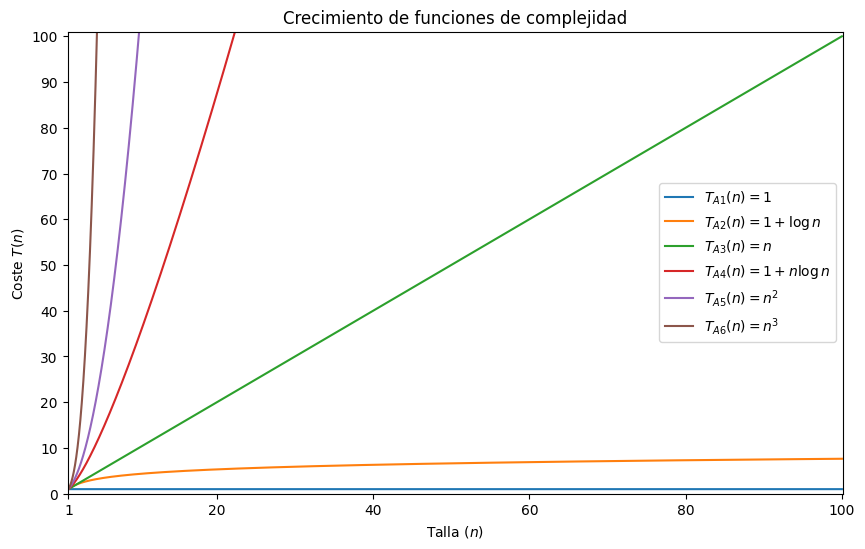

In [53]:
import numpy as np
import matplotlib.pyplot as plt

n = np.linspace(1, 100, 10000)
plt.figure(figsize=(10, 6))

plt.plot(n, np.ones_like(n), label='$T_{A1}(n) = 1$')
plt.plot(n, np.log2(n) + 1, label='$T_{A2}(n) = 1 + \\log n$')
plt.plot(n, n, label='$T_{A3}(n) = n$')
plt.plot(n, n * np.log2(n) + 1, label='$T_{A4}(n) = 1 + n \\log n$')
plt.plot(n, n**2, label='$T_{A5}(n) = n^2$')
plt.plot(n, n**3, label='$T_{A6}(n) = n^3$')

plt.xlabel('Talla ($n$)')
plt.xlim(0.9,100.1)
plt.xticks([1, 20, 40, 60, 80, 100])

plt.ylabel('Coste $T(n)$')
plt.ylim(0, 101)
plt.yticks(range(0,101,10))

plt.title('Crecimiento de funciones de complejidad')
plt.legend()
plt.grid(False)
plt.show()

Aspectos clave:

- Para valores pequeños de $n$, generalmente no hay grandes diferencias.

- Sin embargo, cuando la talla del problema aumenta, las funciones están completamente determinadas por el término dominante.

### Tipo o tasa de crecimiento

Cuando analizamos el coste de un algoritmo, nos interesa conocer su **tipo o tasa de crecimiento** en función de la talla $n$. Esto define el **orden de magnitud** en la que crece la función de coste. 

La comparación de las tasas de crecimiento u órdenes de magnitud de diferentes algoritmos alternativos nos permite seleccionar con criterio objetivo el más eficiente. 

Dadas dos funciones de coste $f(n)$ y $g(n)$ positivas y no decrecientes (monótonas):

- $g(n)$ es de **mayor orden** de magnitud que $f(n)$, si:

$$\lim_{n\to +\infty} \frac{g(n)}{f(n)} = +\infty$$

- $g(n)$ es de **menor orden** de magnitud que $f(n)$, si:

$$\lim_{n\to +\infty} \frac{g(n)}{f(n)} = 0$$

- $g(n)$ y $f(n)$ son de **igual orden** de magnitud, si:

$$\lim_{n\to +\infty} \frac{g(n)}{f(n)} = k$$


### Notación asintótica
* **$O(g(n))$ [O-grande, *big-O*]**: 
    * Se dice que $f(n) \in O(g(n))$ si $g(n)$ es de **igual o mayor** (>=) orden que $f(n)$.
    * $g(n)$ es **cota superior** de $f(n)$.
        * El coste de $f(n)$ no crece más rápido que $g(n)$.
    * Ejemplo: $\;T(n) = n^2 + 7n + 1\;$ p.p. $\; \in \; O(n^3)$

* **$\Omega(g(n))$ [Omega]**: 
    * Se dice que $f(n) \in \Omega(g(n))$ si $g(n)$ es de **menor o igual** (<=) orden que $f(n)$.
    * $g(n)$ es **cota inferior** de $f(n)$: 
        * El coste de $f(n)$ crece al menos tan rápido que $g(n)$.
    * Ejemplo: $\;T(n) = 3\;$ p.p. $\; \in \; \Omega(1)$

* **$\Theta(g(n))$ [Theta]**: 
    * Se dice que $f(n) \in \Theta(g(n))$ si $g(n)$ y $f(n)$ son de **igual** (=) orden.
    * $g(n)$ es **cota ajustada o exacta** de $f(n)$: 
        * El coste de $f(n)$ crece exactamente como $g(n)$.
    * Ejemplo: $\;T(n) = 7n + 1\;$ p.p. $\; \in \; \Theta(n)$

### Jerarquía de órdenes de magnitud

Cuando comparamos tasas de crecimiento entre algoritmos, optaremos por aquellas de menor orden de magnitud. 

Esta es la jerarquía de cotas superiores: 

$$O(1) \subset O(\log n) \subset O(n) \subset O(n \log n) \subset O(n^2) \subset O(n^3) \subset \dots \subset O(2^n) \subset O(n!)$$

### Conveniencia de la notación asintótica

La notación asintótica es especialmente adecuada para comparar el coste de los algoritmos. La medida en pasos de programa expresa el orden de magnitud del coste.

Además, permite identificar rápidamente (con un solo golpe de vista) la complejidad computacional de un método, función, o algoritmo en general:

- $O(1)$: coste constante.
- $O(\log n)$: coste logarítmico.
- $O(n)$: coste lineal.
- $O(n \log n)$: coste lineal-logarítmico.
- $O(n^2)$: coste cuadrático.
- $O(n^3)$: coste cúbico.
- $O(2^n)$: coste exponencial.
- $O(n!)$: coste factorial.

> Es una notación que **se debe de conocer ya que está ampliamente extendida** en el ámbito de la Programación (informes,
documentación, APIs, etc.).


## 5. Estimación de tiempos de ejecución

Una de las ventajas del análisis teórico es que nos permite **realizar estimaciones de tiempo de ejecución sin necesidad de implementar y ejecutar realmente los algoritmos**. 

A continuación se presenta una tabla comparativa del tiempo de ejecución **estimado** para diferentes algoritmos (filas) en función de la talla $n$ (columnas), suponiendo una máquina capaz de ejecutar $10^9$ pasos de programa por segundo (1 GHz).

| $T(n)$ p.p. | $n=1$ | $n=8$ | $n=32$ | $n \approx 10^3$ | $n \approx 10^6$ | $n \approx 10^9$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| $\log_2 n$ | < 1 ns | < 3 ns | 5 ns | 10 ns | 20 ns | 30 ns |
| $n$ | 1 ns | 8 ns | 32 ns | 1 $\mu$ s | 1 ms | 1 s |
| **$n \log_2 n$** | < 1 ns | 24 ns | 160 ns | 10 $\mu$ s | 20 ms | 30 s |
| **$n^2$** | 1 ns | 64 ns | 1 $\mu$ s | 1 ms | 17 min | 31.7 años |
| $n^3$ | 1 ns | 512 ns | 33 $\mu$ s | 1 s | 31.7 años | -- |
| $2^n$ | 2 ns | 256 ns | 4.3 s | -- | -- | -- |
| $n!$ | 1 ns | 40 $\mu$ s | -- | -- | -- | -- |
| $n^n$ | 1 ns | 17 ms | -- | -- | -- | -- |


**Notas explicativas:**
- El orden **$n \log_2 n$** es característico de algoritmos de **ordenación "rápida"** (como *Merge Sort* o *Quick Sort*) y de la **Transformada Rápida de Fourier (FFT)**.
- El orden **$n^2$** es típico de algoritmos de **ordenación "lenta"** (como burbuja o inserción) y de la versión directa de la Transformada de Fourier.

## 6. Análisis por casos. Instancias del problema

El coste temporal de un algoritmo depende fundamentalmente de la talla $n$.

En algunos casos, el coste no solo depende de la talla, sino también de los valores específicos de los datos tratados.

Entonces, para una talla $n$ concreta (fija), el algoritmo mostrará diferentes costes en función de las características de los datos.

Se define **instancia o caso** como el conjunto de todos los datos de la misma talla para los
que el coste temporal es el mismo.

### 6.1 Algoritmos sin instancias diferentes/significativas

Un algoritmo sin instancias diferentes o significativas, es aquel que para una talla $n$ concreta, siempre exhibe el mismo coste temporal, con independencia de los datos que procesa. 

Cuando no hay instancias diferentes, usamos la notación $\Theta(g(n))$ (Theta): **cota ajustada o exacta**. 

#### Ejemplo: imprimir los elementos de una lista

In [ ]:
def imprimir_elementos(lista):
    for elem in lista:
        print(elem)

imprimir_elementos([1,2,3,4])

Análisis de complejidad temporal del algoritmo:

1. **Talla del problema**: 
    - $n = $`len(lista)`, el número de elementos de la lista.
    - En función del tamaño de dicha lista, el algoritmo ejecutará más o menos instrucciones.
2. **Medida de coste temporal**: 
    - Instrucciones críticas.
    - Seleccionamos `print(elem)` como i.c.
3. **Instancias diferentes/significativas?**
    - No, este algoritmo siempre ejecuta los mismos pasos para una talla dada.
4. **Función de coste temporal**:
    - $T(n) = n\;$ i.c. 
5. **Estudio asintótico**:
    - $T(n) \in \Theta(n)\;$ (coste lineal)

Notar que este algoritmo siempre ejecuta $n$ veces la instrucción crítica, con independencia de los datos que almacena la lista.

### 6.2 Algoritmos con instancias diferentes/significativas

Un algoritmo con instancias diferentes o significativas, es aquel que para una talla $n$ concreta, exhibe costes temporales diferentes, en función de los datos que procesa. 

Cuando hay instancias diferentes, se puede formular una función de coste temporal $T^i(n)$ para cada instancia $i$ del problema. 

No obstante, para nuestro análisis estamos interesados únicamente en dos instancias muy particulares y extremas:
- **Mejor caso** $T^m(n)$: 
    - Instancia en la cual el algoritmo exhibe el mínimo coste temporal, ejecutando el mínimo número de instrucciones o de pasos de programa. 
    - Usamos la notación Theta ($\Theta$), proporcionando **cota exacta** para el mejor caso.
        - $T^m(n) \in \Theta(g_m(n))$
        - No obstante, en la función de coste original, el **mejor** caso definirá la cota **inferior** del coste. 
- **Peor caso** $T^p(n)$: 
    - instancia en la cual el algoritmo exhibe el máximo coste temporal, ejecutando el máximo número de instrucciones o de pasos de programa.
    - Usamos la notación Theta ($\Theta$), proporcionando **cota exacta** para el peor caso. 
        - $T^p(n) \in \Theta(g_p(n))$
        - No obstante, en la función de coste original, el **peor** caso definirá la cota **superior** del coste. 


El **coste asintótico $T(n)$ del algoritmo** se expresará como la intersección de las cotas inferiores y superiores definidas por el caso peor y mejor, respectivamente:

$$T(n) \; \in \; \Omega(g_m(n)) \cap O(g_p(n))$$

#### Ejemplo: Búsqueda de la posición de un elemento en una lista

In [ ]:
def buscar(lista, elem):
    i = 0
    while i < len(lista) and lista[i] != elem:
        i += 1
    return i

print(buscar([5,3,1,0,4,1,0,3], 0))

Análisis de complejidad temporal del algoritmo:

1. **Talla del problema**: 
    - $n = $`len(lista)`, el número de elementos de la lista.
2. **Medida de coste temporal**: 
    - Instrucciones críticas.
    - Seleccionamos `i < len(lista)` como i.c.
3. **Instancias diferentes/significativas?**
    - Sí, ya que en función de si `elem` se encuentra en la lista o no y qué posición ocupa en ella, el algoritmo terminará antes o después.
        - Mejor caso: el elemento buscado se encuetra en la posición 0 de la lista.
        - Peor caso: el elemento buscado no se encuentra en la lista.
4. **Funciones de coste temporal:**
    - Mejor caso: $T^m(n) = 1\;$ i.c. 
    - Peor caso: $T^p(n) = n + 1\;$ i.c. 
5. **Estudio asintótico:**
    - $T^m(n) \in \Theta(1)\;$ (coste constante)
    - $T^p(n) \in \Theta(n)\;$ (coste lineal)
    - $T(n) \in \Omega(1) \cap O(n)\;$ 

## Resumen

* La **eficiencia algorítmica** se mide por el consumo de tiempo y memoria.
* El **análisis teórico** se abstrae del hardware, centrándose en construir funciones de coste $T(n)$ dependientes de la **talla ($n$)**, que es una medida del volumen de datos a procesar.
* Los **pasos del programa** o la **instrucción crítica** son unidades de medida que nos permiten simplificar enormemente el cálculo de $T(n)$.
* La **notación asintótica** ($O, \Omega, \Theta$) clasifica los algoritmos por su tasa de crecimiento y proporciona cotas de complejidad.
* El análisis de algoritmos requiere identificar si el algoritmo presenta **instancias diferentes** o no; y en caso afirmativo, los casos mejor y peor, definiendo cotas de complejidad inferiores i superiores.  